# WIMP Dark Matter in Alternative Cosmologies - Results

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from scipy.integrate import solve_ivp

import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
import matplotlib.ticker as ticker

import pandas as pd
import seaborn as sns

from pinn import PINN
import utils

In [2]:
plt.rcParams.update({
    "savefig.dpi": 200,
    "text.usetex": True,
    "font.family": "serif",
    "font.sans-serif": ["Computer Modern Sans Serif"],
    'text.latex.preamble': r'\usepackage{amsfonts}'})

In [3]:
z0 = utils.Z0
zf = utils.ZF

g = utils.G
g_asts = utils.G_ASTS

w0 = utils.W0
wf = utils.WF

w_n = -wf

C_std = utils.C_STD

C_rs = utils.C_RS
C_gb = utils.C_GB

gamma_std = utils.GAMMA_STD
gamma_rs = utils.GAMMA_RS
gamma_gb = utils.GAMMA_GB

zt1 = utils.ZT1

# initial condition for solve_ivp
y0 = np.array([w0])
  
# values of time 
num_coloc = 1000
z_co_np = np.linspace(z0, zf, num_coloc)
z_co = torch.tensor(z_co_np, dtype=torch.float32).view(-1, 1).requires_grad_(True)

In [4]:
def w_eq_fem(z):
    """
    Computes the equilibrium yield W_eq for the finite element method.

    Parameters:
        z (float): The logarithm of x = m_DM / T.
        
    Returns:
        float: The definition of W_eq.
    """
    
    return np.log(45.0 / np.sqrt(32.0 * np.pi**7) * g / g_asts) + 1.5 * z - np.exp(z)

In [5]:
def returns_dwdz(z, w, C, gamma): 
    """
    Computes the derivative of the Boltzmann equation for comparison purposes.

    Parameters:
        z (float): The logarithm of x = m_DM / T.
        w (float): The logarithm of Y, the number density of DM.
        C (float): Proxy for the cross-section.
        gamma (float): Power-law parameter.
        
    Returns:
        float: The derivative of the Boltzmann equation.
    """
    return np.exp(C - gamma * max(0, zt1 - z) - z) * (np.exp(2.0 * w_eq_fem(z) - w) - np.exp(w))

## Relevant loss functions

In [6]:
def make_loss_norm(C, normalize_jac):
    def pinn_loss(self, x):
            
        x = x.clone().detach().requires_grad_(True)

        # Forward pass
        w = self.forward(x)

        # dy/dx via autograd
        dw_z = torch.autograd.grad(
            outputs=w,
            inputs=x,
            grad_outputs=torch.ones_like(w),
            create_graph=True,
            retain_graph=True
        )[0]

        lhs = dw_z * w_n
        rhs = torch.exp(C - z_co) * (torch.exp(2 * w_eq(z_co) - w * w_n) - torch.exp(w * w_n))

        # Absolute jacobian (which will normalize the residuals)
        jacobian = torch.exp(C - z_co) * (torch.exp(2 * w_eq(z_co) - w * w_n) + torch.exp(w * w_n)) # Since the exponentials are always positive, we just remove the global minus sign to obtain the absolute value

        residual = (lhs - rhs)
        ode_loss = torch.mean(residual**2 / (1.0 + normalize_jac * jacobian**2))
        x0_loss = torch.square(w[0] - w0 / w_n)

        total_loss = ode_loss + x0_loss
        
        return ode_loss, x0_loss, total_loss
    return pinn_loss

In [7]:
def make_loss_rba(C):
    def pinn_loss(self, x, lbd_r):
            
        x = x.clone().detach().requires_grad_(True)

        # Forward pass
        w = self.forward(x)

        # dy/dx via autograd
        dw_z = torch.autograd.grad(
            outputs=w,
            inputs=x,
            grad_outputs=torch.ones_like(w),
            create_graph=True,
            retain_graph=True
        )[0]

        lhs = dw_z * w_n * torch.exp(-C)
        rhs = torch.exp(z_co) * (torch.exp(2 * w_eq(z_co) - w * w_n) - torch.exp(w * w_n))

        # Absolute jacobian (which will normalize the residuals)
        jacobian = torch.exp(C - z_co) * (torch.exp(2 * w_eq(z_co) - w * w_n) + torch.exp(w * w_n)) # Since the exponentials are always positive, we just remove the global minus sign to obtain the absolute value

        residual = (lhs - rhs)
        ode_loss = torch.mean((lbd_r*residual)**2)
        x0_loss = torch.square(w[0] - w0 / w_n)

        total_loss = ode_loss + x0_loss
        
        return ode_loss, x0_loss, total_loss, residual, lbd_r
    return pinn_loss

In [8]:
def make_loss_soft(C):
    def pinn_loss(self, x, lbd_r, lbd_0):
            
        x = x.clone().detach().requires_grad_(True)

        # Forward pass
        w = self.forward(x)

        # dy/dx via autograd
        dw_z = torch.autograd.grad(
            outputs=w,
            inputs=x,
            grad_outputs=torch.ones_like(w),
            create_graph=True,
            retain_graph=True
        )[0]

        lhs = dw_z * w_n * torch.exp(-C)
        rhs = torch.exp(-z_co) * (torch.exp(2 * w_eq(z_co) - w * w_n) - torch.exp(w * w_n))

        residual = (lhs - rhs)
        ode_loss = torch.mean(self.mask_fn(lbd_r) * torch.square(residual))
        x0_loss = torch.mean(self.mask_fn(lbd_0) * torch.square(w[0] - w0 / w_n))

        ode_unmasked = torch.mean(residual**2)
        x0_unmasked = torch.square(w[0] - w0 / w_n)

        total_loss = ode_loss + x0_loss
        
        return ode_loss, x0_loss, total_loss, ode_unmasked, x0_unmasked, lbd_r, lbd_0
    return pinn_loss

In [9]:
# Font sizes and spacing
font_size  = 30     # Font size for tick labels and legend text
title_size = 32     # Font size for plot title
tick_pad   = 10     # Padding (points) between ticks and their labels

# Line and marker settings
col_unnorm = "blue"     # Unnormalized (vanilla) PINN
col_norm   = "magenta"  # Jacobian-normalized PINN
col_rba    = "seagreen" # Residual-Based Attention (emphasizes large PDE residual regions)
col_soft   = "peru"     # Soft Attention (smooth, global reweighting of the loss)

lw_fit = 3.2        # Line width for plotted lines (fits or connecting curves)
ms     = 12         # Scatter marker scale (you use s=ms**2, so area scales like ms^2)
mew    = 2.2        # Marker edge width (stroke thickness), also used for 'x' linewidth

## Ablation test

### Without sigmoid

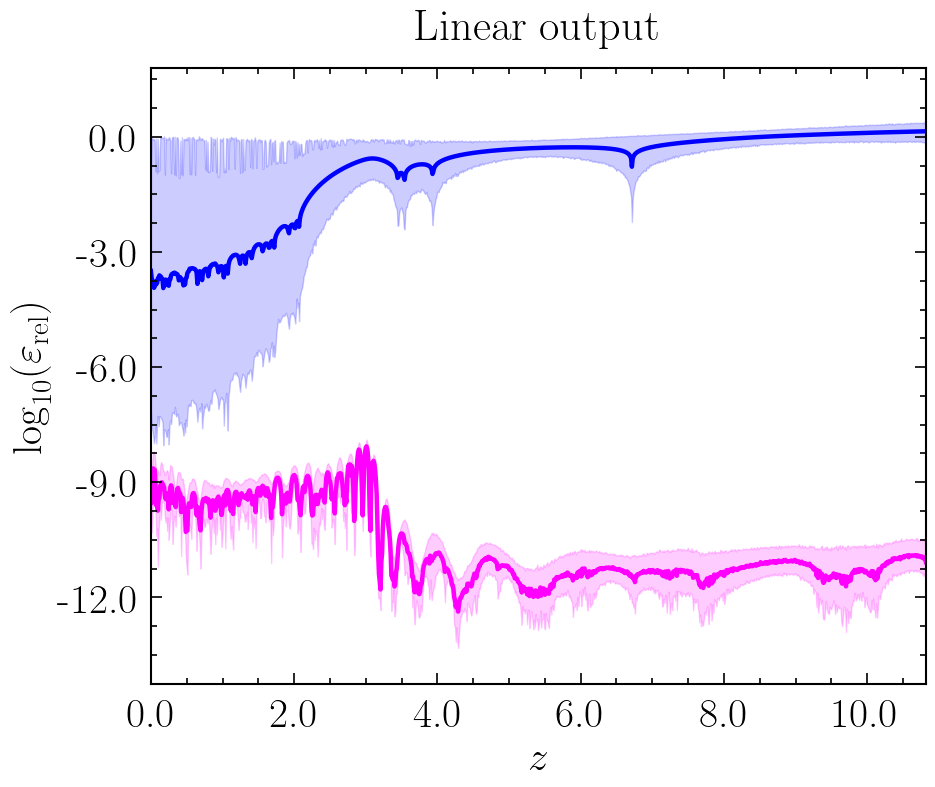

In [10]:
ablation_norm = np.log10(1.0e-15 + np.loadtxt('./dataFreezeOut/AblationTest-normTrue-SigmoidFalse.txt'))
ablation_unnorm = np.log10(1.0e-15 + np.loadtxt('./dataFreezeOut/AblationTest-normFalse-SigmoidFalse.txt'))

df_norm = pd.DataFrame(ablation_norm)
df_norm['trial'] = df_norm.index
df_norm_long = df_norm.melt(id_vars='trial', var_name='x_index', value_name='value')
df_norm_long['x'] = df_norm_long['x_index'].astype(int).map(dict(enumerate(z_co_np)))

df_unnorm = pd.DataFrame(ablation_unnorm)
df_unnorm['trial'] = df_unnorm.index
df_unnorm_long = df_unnorm.melt(id_vars='trial', var_name='x_index', value_name='value')
df_unnorm_long['x'] = df_unnorm_long['x_index'].astype(int).map(dict(enumerate(z_co_np)))

# Create the plot
fig, ax = plt.subplots(figsize=(10, 8))

# Axis styling
plt.setp(ax.spines.values(), linewidth=1.50)
ax.set_axisbelow(False)

# Limits and labels
ax.set_xlim(0, np.log(50000))
ax.set_ylim(-14.25, 1.8)
ax.set_xlabel(r"$z$", fontsize=font_size)
ax.set_ylabel(r"$\log_{10}(\varepsilon_\mathrm{rel})$", fontsize=font_size)
ax.set_title("Linear output", fontsize=title_size, pad=20)

# Seaborn lines (ONE LINE EACH)
sns.lineplot(data=df_unnorm_long, x="x", y="value", errorbar="ci", color=col_unnorm, lw=lw_fit, ax=ax)
sns.lineplot(data=df_norm_long,   x="x", y="value", errorbar="ci", color=col_norm,   lw=lw_fit, ax=ax)

# Tick styling
ax.xaxis.set_major_locator(ticker.MultipleLocator(2))
ax.xaxis.set_major_formatter(ticker.FormatStrFormatter("%.1f"))
ax.yaxis.set_major_locator(ticker.MultipleLocator(3))
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.1f"))
ax.tick_params(axis="both", which="major", direction="in", bottom=True, top=True, left=True, right=True, length=8, width=1.2, pad=tick_pad, labelsize=font_size)
ax.tick_params(axis="both", which="minor", direction="in", bottom=True, top=True, left=True, right=True, length=4, width=1.2)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())

# Save and show
fig.savefig("AblationTest-SigmoidFalse.png", bbox_inches="tight", dpi=500, pad_inches=0.01)
plt.show()


### With sigmoid

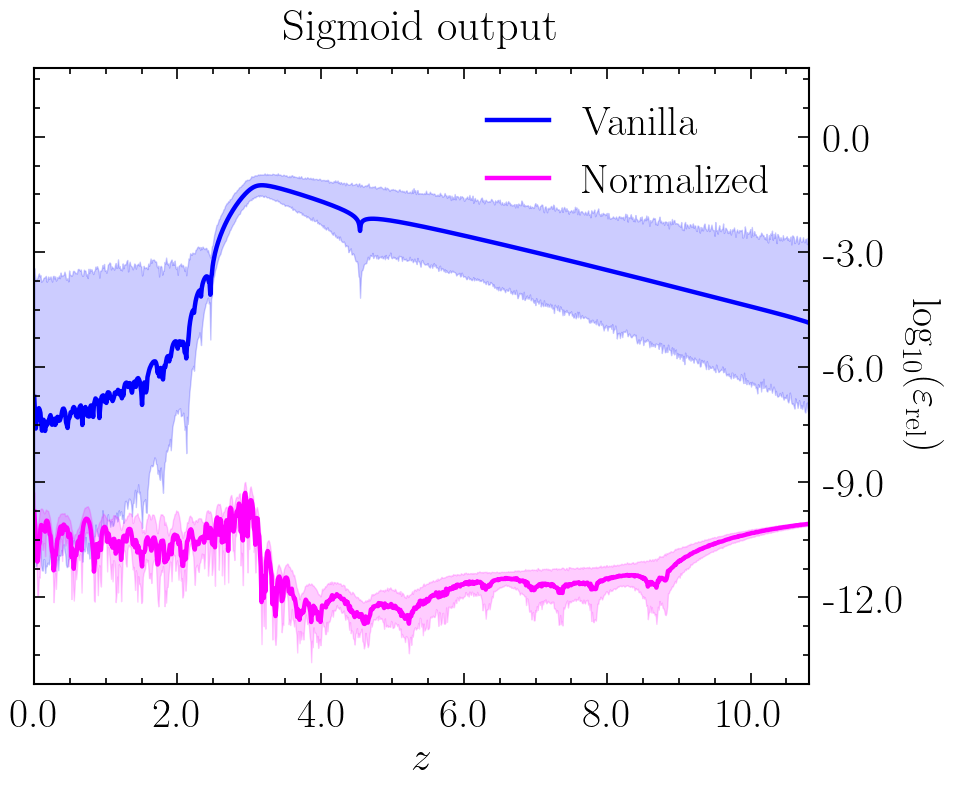

In [11]:
ablation_norm = np.log10(1.0e-15 + np.loadtxt('./dataFreezeOut/AblationTest-normTrue-SigmoidTrue.txt'))
ablation_unnorm = np.log10(1.0e-15 + np.loadtxt('./dataFreezeOut/AblationTest-normFalse-SigmoidTrue.txt'))

df_norm = pd.DataFrame(ablation_norm)
df_norm['trial'] = df_norm.index
df_norm_long = df_norm.melt(id_vars='trial', var_name='x_index', value_name='value')
df_norm_long['x'] = df_norm_long['x_index'].astype(int).map(dict(enumerate(z_co_np)))

df_unnorm = pd.DataFrame(ablation_unnorm)
df_unnorm['trial'] = df_unnorm.index
df_unnorm_long = df_unnorm.melt(id_vars='trial', var_name='x_index', value_name='value')
df_unnorm_long['x'] = df_unnorm_long['x_index'].astype(int).map(dict(enumerate(z_co_np)))

# Create the plot
fig, ax = plt.subplots(figsize=(10, 8))

# Axis styling
plt.setp(ax.spines.values(), linewidth=1.50)
ax.set_axisbelow(False)

# Limits and labels
ax.set_xlim(0, np.log(50000))
ax.set_ylim(-14.25, 1.8)
ax.set_xlabel(r"$z$", fontsize=font_size)
ax.set_ylabel(r"$\log_{10}(\varepsilon_\mathrm{rel})$", rotation=270, fontsize=font_size, labelpad=30)
ax.yaxis.set_label_position("right")
ax.yaxis.tick_right()
ax.set_title("Sigmoid output", fontsize=title_size, pad=20)

# Seaborn lines (ONE LINE EACH)
sns.lineplot(data=df_unnorm_long, x="x", y="value", errorbar="ci", color=col_unnorm, lw=lw_fit, label="Vanilla"   , ax=ax)
sns.lineplot(data=df_norm_long,   x="x", y="value", errorbar="ci", color=col_norm,   lw=lw_fit, label="Normalized", ax=ax)

# Tick styling
ax.xaxis.set_major_locator(ticker.MultipleLocator(2))
ax.xaxis.set_major_formatter(ticker.FormatStrFormatter("%.1f"))
ax.yaxis.set_major_locator(ticker.MultipleLocator(3))
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.1f"))
ax.tick_params(axis="both", which="major", direction="in", bottom=True, top=True, left=True, right=True, length=8, width=1.2, pad=tick_pad, labelsize=font_size)
ax.tick_params(axis="both", which="minor", direction="in", bottom=True, top=True, left=True, right=True, length=4, width=1.2)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())

# Legend
ax.legend(fontsize=font_size, frameon=False, loc="upper right", handlelength=1.48)

# Save and show
fig.savefig("AblationTest-SigmoidTrue.png", bbox_inches="tight", dpi=500, pad_inches=0.01)
plt.show()

## Stiffness strategies in PINNs

### Yield as a function of z without sigmoid

In [12]:
loss_control = make_loss_norm(C_std, False)
model_control = PINN(40, 4, 1, 1.0e-3, loss_control)

loss_norm = make_loss_norm(C_std, True)
model_norm = PINN(40, 4, 1, 1.0e-3, loss_norm)

loss_rba = make_loss_rba(C_std)
model_rba = PINN(40, 4, 1, 1.0e-3, loss_rba)

loss_soft = make_loss_soft(C_std)
model_soft = PINN(40, 4, 1, 1.0e-3, loss_soft)

model_control.load_state_dict(torch.load('./dataFreezeOut/best-FwdStd-normFalse-SigmoidFalse' + str(int(np.floor(C_std))) + '.pt'))
model_norm.load_state_dict(torch.load('./dataFreezeOut/best-FwdStd-normTrue-SigmoidFalse' + str(int(np.floor(C_std))) + '.pt'))
model_rba.load_state_dict(torch.load('./dataFreezeOut/best-FwdStd-RBA-SigmoidFalse.pt'))
model_soft.load_state_dict(torch.load('./dataFreezeOut/best-FwdStd-Soft-SigmoidFalse.pt'))

<All keys matched successfully>

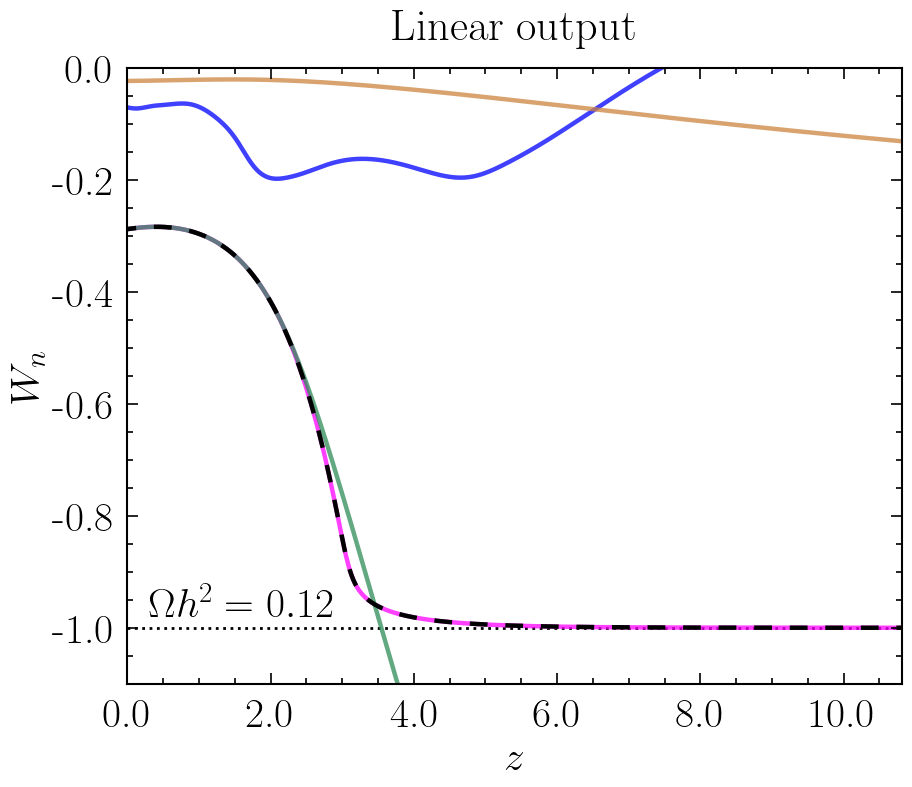

In [13]:
sol_std = solve_ivp(returns_dwdz, [z0, zf], y0, method='BDF', t_eval=z_co_np, args=[C_std, gamma_std], dense_output=True, rtol=1e-7, atol=1e-9)

pred_control = model_control.predict(z_co)
pred_norm = model_norm.predict(z_co)
pred_rba = model_rba.predict(z_co)
pred_soft = model_soft.predict(z_co)

# Create the plot
fig, ax = plt.subplots(figsize=(10, 8))

# Axis styling
plt.setp(ax.spines.values(), linewidth=1.50)
ax.set_axisbelow(False)

# Curves
ax.plot(z_co_np, pred_control, color=col_unnorm, alpha=0.75, lw=lw_fit, label="Control", zorder=2.1)
ax.plot(z_co_np, pred_norm   , color=col_norm  , alpha=0.75, lw=lw_fit, label="Normalized PINN", zorder=2.1)
ax.plot(z_co_np, pred_rba    , color=col_rba, alpha=0.75, lw=lw_fit, label="Residual-based attention", zorder=2.1)
ax.plot(z_co_np, pred_soft   , color=col_soft, alpha=0.75, lw=lw_fit, label="Soft attention", zorder=2.1)
ax.plot(sol_std.t, sol_std.y.reshape(-1,) / w_n, linestyle=(2, (4, 4)), color="black", lw=lw_fit, label="FEM", zorder=2.2)

# Reference line and annotation
ax.axhline(y=wf / w_n, color="black", linestyle=":", lw=2, zorder=1.9)
ax.text(0.3, -0.98, r"$\Omega h^2 = 0.12$", fontsize=font_size)

# Limits, labels, title
ax.set_xlim(0, np.log(50000))
ax.set_ylim(-1.1, 0.0)
ax.set_xlabel(r"$z$", fontsize=font_size)
ax.set_ylabel(r"$W_n$", fontsize=font_size)
ax.set_title("Linear output", fontsize=title_size, pad=20)

# Tick styling
ax.xaxis.set_major_locator(ticker.MultipleLocator(2))
ax.xaxis.set_major_formatter(ticker.FormatStrFormatter("%.1f"))
ax.yaxis.set_major_locator(ticker.MultipleLocator(0.2))
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.1f"))
ax.tick_params(axis="both", which="major", direction="in", bottom=True, top=True, left=True, right=True, length=8, width=1.2, pad=tick_pad, labelsize=font_size)
ax.tick_params(axis="both", which="minor", direction="in", bottom=True, top=True, left=True, right=True, length=4, width=1.2)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())

# Save and show
fig.savefig("FwdComparison-SigmoidFalse.png", bbox_inches="tight", dpi=500, pad_inches=0.01)
plt.show()


### Comparison of the weights without sigmoid

In [14]:
def jacobian(w, z):
    """
    Computes the Jacobian of the Boltzmann equation for WIMP dark matter.

    Parameters:
        z (float): The logarithm of x = m_DM / T.
        w (float): The logarithm of Y, the number density of DM.

    Returns:
        float: The Jacobian of the Boltzmann equation.
    """
    return np.exp(C_std - z) * (np.exp(2.0 * w_eq_fem(z) - w * w_n) + np.exp(w * w_n))

In [15]:
WeightsRBA = np.loadtxt('./dataFreezeOut/Weights-RBA-SigmoidFalse.txt')
WeightsSoft = np.loadtxt('./dataFreezeOut/Weights-Soft-SigmoidFalse.txt')

/tmp/ipykernel_7471/1116976906.py:12: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  ax.plot(z_co_np, np.log10(model_soft.mask_fn(torch.tensor(WeightsSoft))), color=col_soft, alpha=0.90, lw=lw_fit, label="Soft attention", zorder=2.1)


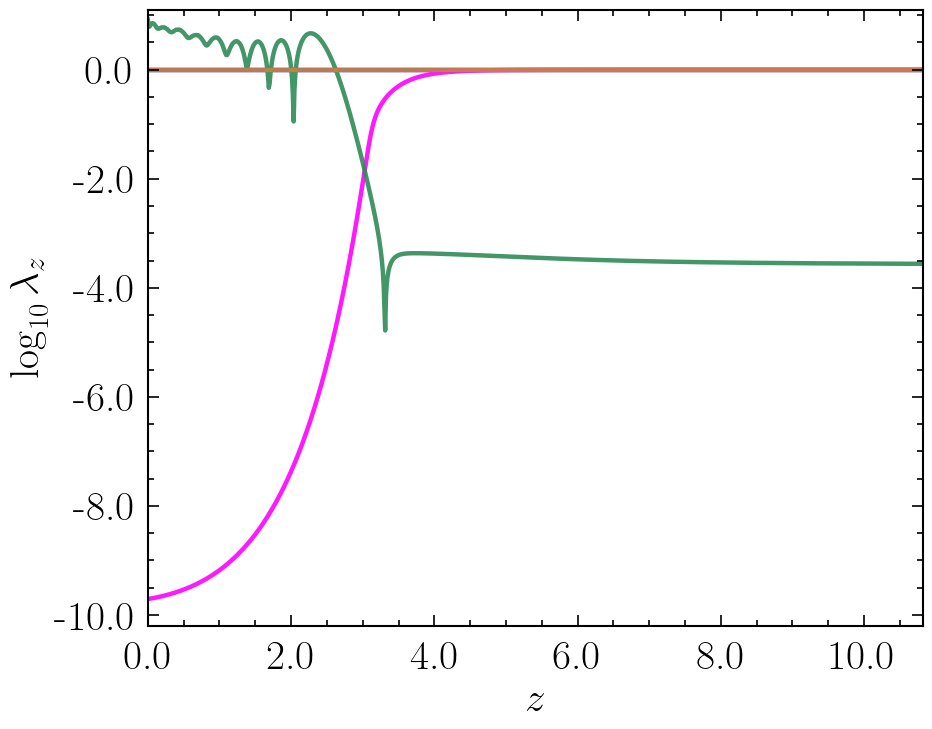

In [16]:
# Create the plot
fig, ax = plt.subplots(figsize=(10, 8))

# Axis styling
plt.setp(ax.spines.values(), linewidth=1.50)
ax.set_axisbelow(False)

# Curves (grayscale-safe: styles + stronger alpha)
ax.plot(z_co_np, np.log10(np.ones(z_co_np.shape[0])), color=col_unnorm, alpha=0.90, lw=lw_fit, label="Control", zorder=2.1)
ax.plot(z_co_np, np.log10(1.0/(1.0 + jacobian(pred_norm.numpy().squeeze(), z_co_np)**2)**0.5), color=col_norm, alpha=0.90, lw=lw_fit, label="Normalized PINN", zorder=2.1)
ax.plot(z_co_np, np.log10(WeightsRBA), color=col_rba, alpha=0.90, lw=lw_fit, label="Residual-based attention", zorder=2.1)
ax.plot(z_co_np, np.log10(model_soft.mask_fn(torch.tensor(WeightsSoft))), color=col_soft, alpha=0.90, lw=lw_fit, label="Soft attention", zorder=2.1)

# Limits and labels
ax.set_xlim(0, np.log(50000))
ax.set_ylim(-10.2, 1.1)
ax.set_xlabel(r"$z$", fontsize=font_size)
ax.set_ylabel(r"$\log_{10}\lambda_z$", fontsize=font_size)

# Tick styling
ax.xaxis.set_major_locator(ticker.MultipleLocator(2))
ax.xaxis.set_major_formatter(ticker.FormatStrFormatter("%.1f"))
ax.yaxis.set_major_locator(ticker.MultipleLocator(2))
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.1f"))
ax.tick_params(axis="both", which="major", direction="in", bottom=True, top=True, left=True, right=True, length=8, width=1.2, pad=tick_pad, labelsize=font_size)
ax.tick_params(axis="both", which="minor", direction="in", bottom=True, top=True, left=True, right=True, length=4, width=1.2)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())

# Save and show
fig.savefig("WeightComparison-SigmoidFalse.png", bbox_inches="tight", dpi=500, pad_inches=0.01)
plt.show()


### Mean relative squared errors without sigmoid

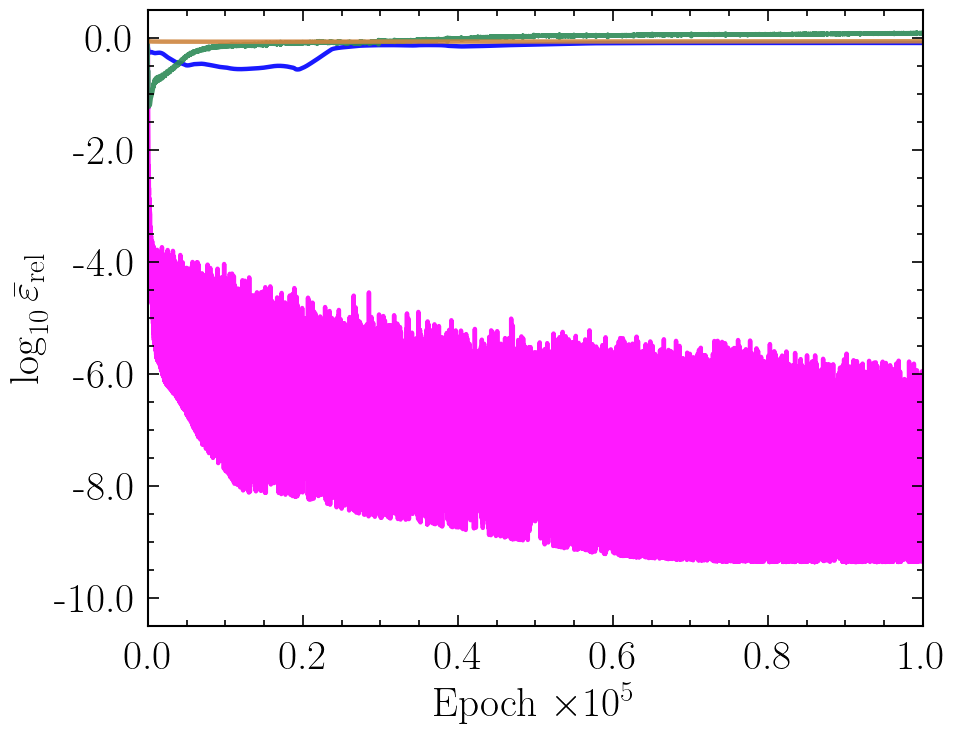

In [17]:
PINNvsFEM_control = np.loadtxt('./dataFreezeOut/PINNvsFEM-normFalse-SigmoidFalse.txt')
PINNvsFEM_Jacobian = np.loadtxt('./dataFreezeOut/PINNvsFEM-normTrue-SigmoidFalse.txt')
PINNvsFEM_RBA = np.loadtxt('./dataFreezeOut/PINNvsFEM-RBA-SigmoidFalse.txt')
PINNvsFEM_Soft = np.loadtxt('./dataFreezeOut/PINNvsFEM-Soft-SigmoidFalse.txt')
epochs = np.arange(0, PINNvsFEM_Jacobian.shape[0], 1, dtype='int32')

# Create the plot
fig, ax = plt.subplots(figsize=(10, 8))

# Axis styling
plt.setp(ax.spines.values(), linewidth=1.50)
ax.set_axisbelow(False)

# Curves (grayscale-safe: styles + stronger alpha)
ax.plot(epochs/1e5, np.log10(PINNvsFEM_control), color=col_unnorm, alpha=0.90, lw=lw_fit, label="Control", zorder=2.1)
ax.plot(epochs/1e5, np.log10(PINNvsFEM_Jacobian), color=col_norm, alpha=0.90, lw=lw_fit, label="Normalized PINN", zorder=2.1)
ax.plot(epochs/1e5, np.log10(PINNvsFEM_RBA), color=col_rba, alpha=0.90, lw=lw_fit, label="Residual-based attention", zorder=2.1)
ax.plot(epochs/1e5, np.log10(PINNvsFEM_Soft), color=col_soft, alpha=0.90, lw=lw_fit, label="Soft attention", zorder=2.1)

# Limits and labels
ax.set_xlim(0, 1.0)
ax.set_ylim(-10.5, 0.5)
ax.set_xlabel(r"Epoch $\times 10^5$", fontsize=font_size)
ax.set_ylabel(r"$\log_{10}\bar{\varepsilon}_\mathrm{rel}$", fontsize=font_size)

# Tick styling
ax.xaxis.set_major_locator(ticker.MultipleLocator(0.2))
ax.xaxis.set_major_formatter(ticker.FormatStrFormatter("%.1f"))
ax.yaxis.set_major_locator(ticker.MultipleLocator(2))
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.1f"))
ax.tick_params(axis="both", which="major", direction="in", bottom=True, top=True, left=True, right=True, length=8, width=1.2, pad=tick_pad, labelsize=font_size)
ax.tick_params(axis="both", which="minor", direction="in", bottom=True, top=True, left=True, right=True, length=4, width=1.2)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())

# Save and show
fig.savefig("MethodComp-SigmoidFalse.png", bbox_inches="tight", dpi=500, pad_inches=0.01)
plt.show()


### Yield as a function of z with sigmoid

In [18]:
loss_control = make_loss_norm(C_std, False)
model_control = PINN(40, 4, 1, 1.0e-3, loss_control, True)

loss_norm = make_loss_norm(C_std, True)
model_norm = PINN(40, 4, 1, 1.0e-3, loss_norm, True)

loss_rba = make_loss_rba(C_std)
model_rba = PINN(40, 4, 1, 1.0e-3, loss_rba, True)

loss_soft = make_loss_soft(C_std)
model_soft = PINN(40, 4, 1, 1.0e-3, loss_soft, True)

model_control.load_state_dict(torch.load('./dataFreezeOut/best-FwdStd-normFalse-SigmoidTrue' + str(int(np.floor(C_std))) + '.pt'))
model_norm.load_state_dict(torch.load('./dataFreezeOut/best-FwdStd-normTrue-SigmoidTrue' + str(int(np.floor(C_std))) + '.pt'))
model_rba.load_state_dict(torch.load('./dataFreezeOut/best-FwdStd-RBA-SigmoidTrue.pt'))
model_soft.load_state_dict(torch.load('./dataFreezeOut/best-FwdStd-Soft-SigmoidTrue.pt'))

<All keys matched successfully>

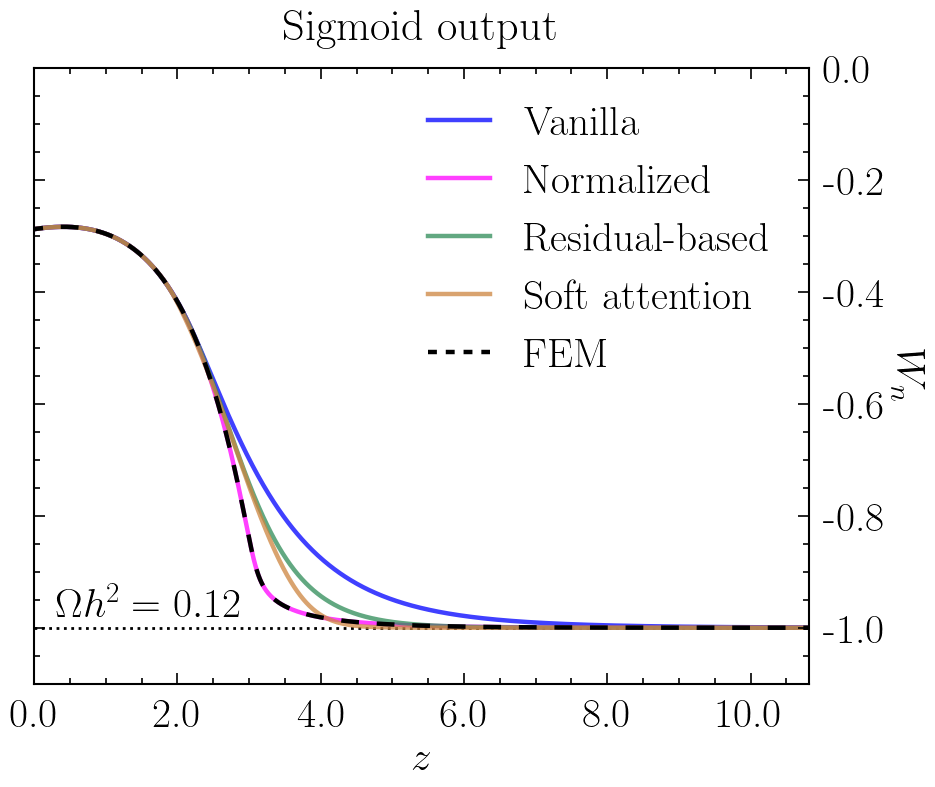

In [19]:
sol_std = solve_ivp(returns_dwdz, [z0, zf], y0, method='BDF', t_eval=z_co_np, args=[C_std, gamma_std], dense_output=True, rtol=1e-7, atol=1e-9)

pred_control = model_control.predict(z_co)
pred_norm = model_norm.predict(z_co)
pred_rba = model_rba.predict(z_co)
pred_soft = model_soft.predict(z_co)

# Create the plot
fig, ax = plt.subplots(figsize=(10, 8))

# Axis styling
plt.setp(ax.spines.values(), linewidth=1.50)
ax.set_axisbelow(False)

# Curves
ax.plot(z_co_np, pred_control, color=col_unnorm, alpha=0.75, lw=lw_fit, label="Vanilla", zorder=2.1)
ax.plot(z_co_np, pred_norm   , color=col_norm  , alpha=0.75, lw=lw_fit, label="Normalized", zorder=2.1)
ax.plot(z_co_np, pred_rba    , color=col_rba, alpha=0.75, lw=lw_fit, label="Residual-based", zorder=2.1)
ax.plot(z_co_np, pred_soft   , color=col_soft, alpha=0.75, lw=lw_fit, label="Soft attention", zorder=2.1)
ax.plot(sol_std.t, sol_std.y.reshape(-1,) / w_n, linestyle=(2, (4, 4)), color="black", lw=lw_fit, label="FEM", zorder=2.2)

# Reference line and annotation
ax.axhline(y=wf / w_n, color="black", linestyle=":", lw=2, zorder=1.9)
ax.text(0.3, -0.98, r"$\Omega h^2 = 0.12$", fontsize=font_size)

# Limits, labels, title
ax.set_xlim(0, np.log(50000))
ax.set_ylim(-1.1, 0.0)
ax.set_xlabel(r"$z$", fontsize=font_size)
ax.set_ylabel(r"$W_n$", fontsize=font_size, rotation=270, labelpad=30)
ax.set_title("Sigmoid output", fontsize=title_size, pad=20)
ax.yaxis.tick_right()
ax.yaxis.set_label_position("right")

# Tick styling
ax.xaxis.set_major_locator(ticker.MultipleLocator(2))
ax.xaxis.set_major_formatter(ticker.FormatStrFormatter("%.1f"))
ax.yaxis.set_major_locator(ticker.MultipleLocator(0.2))
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.1f"))
ax.tick_params(axis="both", which="major", direction="in", bottom=True, top=True, left=True, right=True, length=8, width=1.2, pad=tick_pad, labelsize=font_size)
ax.tick_params(axis="both", which="minor", direction="in", bottom=True, top=True, left=True, right=True, length=4, width=1.2)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())

# Legend
leg = ax.legend(fontsize=font_size, frameon=False, loc="upper right", handlelength=1.5)

for line in leg.get_lines():
    if line.get_label() == "FEM":
        line.set_linestyle((0, (2, 2)))  # Set dense dashes ONLY in legend
        line.set_linewidth = lw_fit

# Save and show
fig.savefig("FwdComparison-SigmoidTrue.png", bbox_inches="tight", dpi=500, pad_inches=0.01)
plt.show()

In [20]:
WeightsRBA = np.loadtxt('./dataFreezeOut/Weights-RBA-SigmoidTrue.txt')
WeightsSoft = np.loadtxt('./dataFreezeOut/Weights-Soft-SigmoidTrue.txt')

/tmp/ipykernel_7471/3094092424.py:12: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  ax.plot(z_co_np, np.log10(model_soft.mask_fn(torch.tensor(WeightsSoft))), color=col_soft, alpha=0.90, lw=lw_fit, label="Soft attention", zorder=2.1)


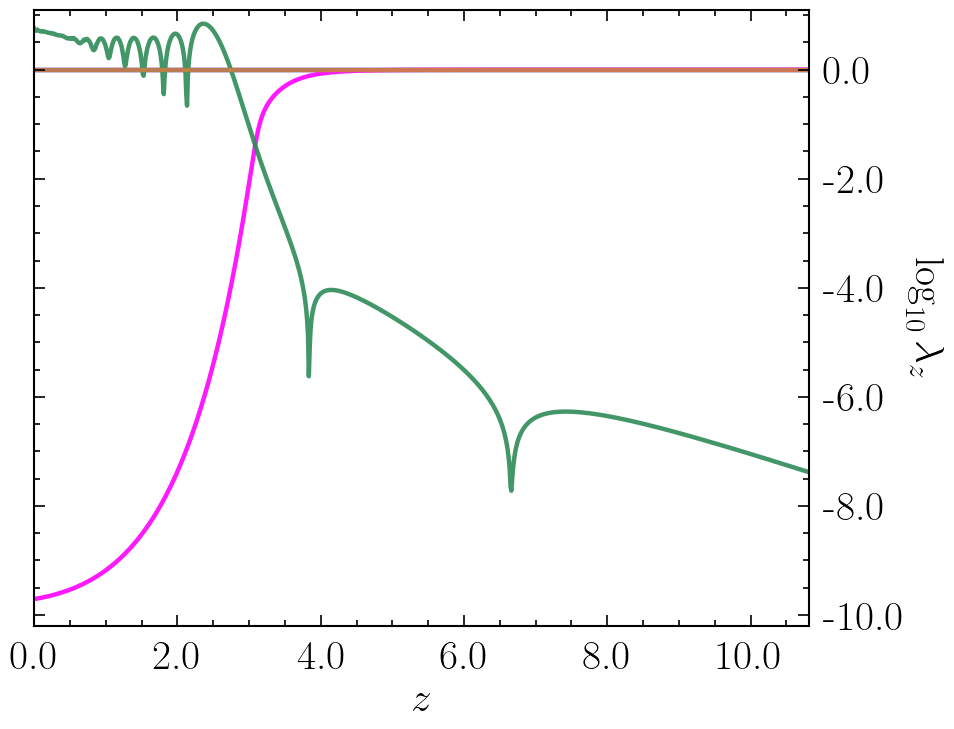

In [21]:
# Create the plot
fig, ax = plt.subplots(figsize=(10, 8))

# Axis styling
plt.setp(ax.spines.values(), linewidth=1.50)
ax.set_axisbelow(False)

# Curves (grayscale-safe: styles + stronger alpha)
ax.plot(z_co_np, np.log10(np.ones(z_co_np.shape[0])), color=col_unnorm, alpha=0.90, lw=lw_fit, label="Control", zorder=2.1)
ax.plot(z_co_np, np.log10(1.0/(1.0 + jacobian(pred_norm.numpy().squeeze(), z_co_np)**2)**0.5), color=col_norm, alpha=0.90, lw=lw_fit, label="Normalized PINN", zorder=2.1)
ax.plot(z_co_np, np.log10(WeightsRBA), color=col_rba, alpha=0.90, lw=lw_fit, label="Residual-based attention", zorder=2.1)
ax.plot(z_co_np, np.log10(model_soft.mask_fn(torch.tensor(WeightsSoft))), color=col_soft, alpha=0.90, lw=lw_fit, label="Soft attention", zorder=2.1)

# Limits and labels
ax.set_xlim(0, np.log(50000))
ax.set_ylim(-10.2, 1.1)
ax.set_xlabel(r"$z$", fontsize=font_size)
ax.set_ylabel(r"$\log_{10}\lambda_z$", fontsize=font_size, rotation=270, labelpad=30)
ax.yaxis.tick_right()
ax.yaxis.set_label_position("right")

# Tick styling
ax.xaxis.set_major_locator(ticker.MultipleLocator(2))
ax.xaxis.set_major_formatter(ticker.FormatStrFormatter("%.1f"))
ax.yaxis.set_major_locator(ticker.MultipleLocator(2))
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.1f"))
ax.tick_params(axis="both", which="major", direction="in", bottom=True, top=True, left=True, right=True, length=8, width=1.2, pad=tick_pad, labelsize=font_size)
ax.tick_params(axis="both", which="minor", direction="in", bottom=True, top=True, left=True, right=True, length=4, width=1.2)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())

# Save and show
fig.savefig("WeightComparison-SigmoidTrue.png", bbox_inches="tight", dpi=500, pad_inches=0.01)
plt.show()

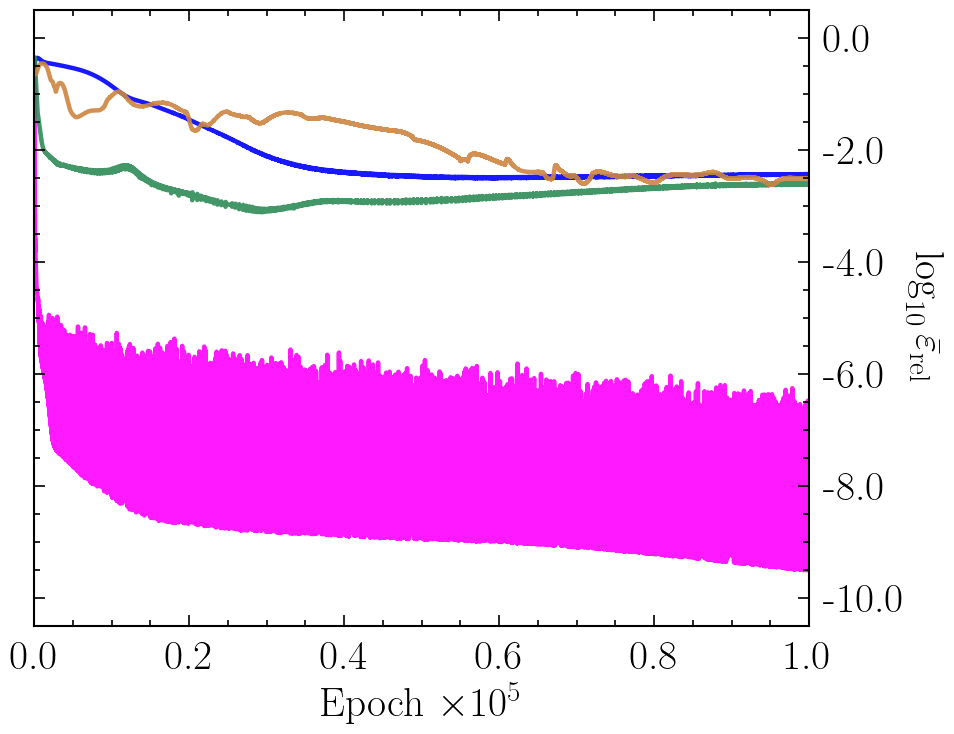

In [22]:
PINNvsFEM_control = np.loadtxt('./dataFreezeOut/PINNvsFEM-normFalse-SigmoidTrue.txt')
PINNvsFEM_Jacobian = np.loadtxt('./dataFreezeOut/PINNvsFEM-normTrue-SigmoidTrue.txt')
PINNvsFEM_RBA = np.loadtxt('./dataFreezeOut/PINNvsFEM-RBA-SigmoidTrue.txt')
PINNvsFEM_Soft = np.loadtxt('./dataFreezeOut/PINNvsFEM-Soft-SigmoidTrue.txt')
epochs = np.arange(0, PINNvsFEM_Jacobian.shape[0], 1, dtype='int32')

# Create the plot
fig, ax = plt.subplots(figsize=(10, 8))

# Axis styling
plt.setp(ax.spines.values(), linewidth=1.50)
ax.set_axisbelow(False)

# Curves (grayscale-safe: styles + stronger alpha)
ax.plot(epochs/1e5, np.log10(PINNvsFEM_control), color=col_unnorm, alpha=0.90, lw=lw_fit, label="Control", zorder=2.1)
ax.plot(epochs/1e5, np.log10(PINNvsFEM_Jacobian), color=col_norm, alpha=0.90, lw=lw_fit, label="Normalized PINN", zorder=2.1)
ax.plot(epochs/1e5, np.log10(PINNvsFEM_RBA), color=col_rba, alpha=0.90, lw=lw_fit, label="Residual-based attention", zorder=2.1)
ax.plot(epochs/1e5, np.log10(PINNvsFEM_Soft), color=col_soft, alpha=0.90, lw=lw_fit, label="Soft attention", zorder=2.1)

# Limits and labels
ax.set_xlim(0, 1.0)
ax.set_ylim(-10.5, 0.5)
ax.set_xlabel(r"Epoch $\times 10^5$", fontsize=font_size)
ax.set_ylabel(r"$\log_{10}\bar{\varepsilon}_\mathrm{rel}$", fontsize=font_size, rotation=270, labelpad=30)
ax.yaxis.tick_right()
ax.yaxis.set_label_position("right")

# Tick styling
ax.xaxis.set_major_locator(ticker.MultipleLocator(0.2))
ax.xaxis.set_major_formatter(ticker.FormatStrFormatter("%.1f"))
ax.yaxis.set_major_locator(ticker.MultipleLocator(2))
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.1f"))
ax.tick_params(axis="both", which="major", direction="in", bottom=True, top=True, left=True, right=True, length=8, width=1.2, pad=tick_pad, labelsize=font_size)
ax.tick_params(axis="both", which="minor", direction="in", bottom=True, top=True, left=True, right=True, length=4, width=1.2)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())

# Save and show
fig.savefig("MethodComp-SigmoidTrue.png", bbox_inches="tight", dpi=500, pad_inches=0.01)
plt.show()

## Inverse problems: from data to possible physical models

### Yield as a function of $z$ for Standard and alternative cosmologies

In [23]:
def make_loss(C, normalize_jac, gamma):
    def pinn_loss(self, x):
            
        x = x.clone().detach().requires_grad_(True)

        # Forward pass
        w = self.forward(x)

        # dy/dx via autograd
        dw_z = torch.autograd.grad(
            outputs=w,
            inputs=x,
            grad_outputs=torch.ones_like(w),
            create_graph=True,
            retain_graph=True
        )[0]

        lhs = dw_z * w_n
        rhs = torch.exp(C - gamma * torch.relu(zt1 - z_co) - z_co) * (torch.exp(2 * w_eq(z_co) - w * w_n) - torch.exp(w * w_n))

        # Absolute jacobian (which will normalize the residuals)
        jacobian = torch.exp(C - gamma * torch.relu(zt1 - z_co) - z_co) * (torch.exp(2 * w_eq(z_co) - w * w_n) + torch.exp(w * w_n)) # Since the exponentials are always positive, we just remove the global minus sign to obtain the absolute value

        residual = (lhs - rhs)
        ode_loss = torch.mean(residual**2 / (1.0 + normalize_jac * jacobian**2))
        x0_loss = torch.square(w[0] - w0 / w_n)
        xf_loss = torch.square(w[-1] - wf / w_n)

        total_loss = ode_loss + x0_loss + xf_loss
        
        return ode_loss, x0_loss, xf_loss, total_loss
    return pinn_loss

In [24]:
loss_std = make_loss(C_std, True, gamma_std)
model_std = PINN(40, 4, 1, 1.0e-3, loss_std, False, torch.tensor(C_std))

loss_rs = make_loss(C_rs, True, gamma_rs)
model_rs = PINN(40, 4, 1, 1.0e-3, loss_rs, False, torch.tensor(C_rs))

loss_gb = make_loss(C_gb, True, gamma_gb)
model_gb = PINN(40, 4, 1, 1.0e-3, loss_gb, False, torch.tensor(C_gb))

model_std.load_state_dict(torch.load('./dataFreezeOut/best-InvStd-normTrue.pt'))
model_rs.load_state_dict(torch.load('./dataFreezeOut/best-InvRS-normTrue.pt'))
model_gb.load_state_dict(torch.load('./dataFreezeOut/best-InvGB-normTrue.pt'))

<All keys matched successfully>

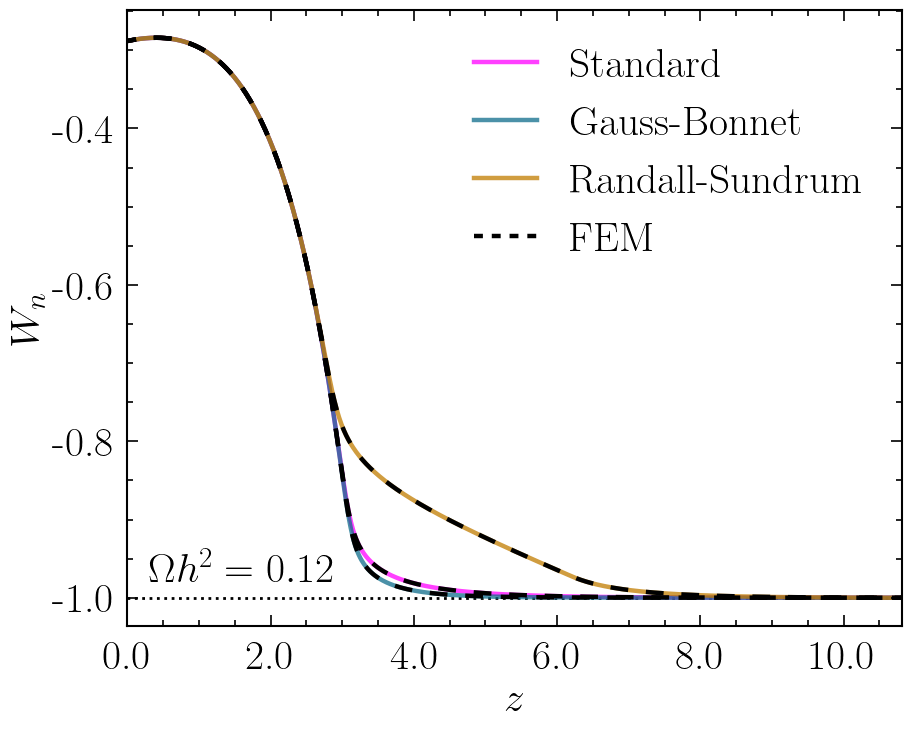

In [25]:
# solving ODE
sol_std = solve_ivp(returns_dwdz, [z0, zf], y0, method='BDF', t_eval=z_co_np, args=[C_std, gamma_std], dense_output=True, rtol=1e-7, atol=1e-9) 
sol_gb = solve_ivp(returns_dwdz, [z0, zf], y0, method='BDF', t_eval=z_co_np, args=[C_gb, gamma_gb], dense_output=True, rtol=1e-7, atol=1e-9) 
sol_rs = solve_ivp(returns_dwdz, [z0, zf], y0, method='BDF', t_eval=z_co_np, args=[C_rs, gamma_rs], dense_output=True, rtol=1e-7, atol=1e-9)

pred_std = model_std.predict(z_co)
pred_gb = model_gb.predict(z_co)
pred_rs = model_rs.predict(z_co)
 
# Create the plot
fig, ax = plt.subplots(figsize=(10, 8))

# Axis styling
plt.setp(ax.spines.values(), linewidth=1.50)
ax.set_axisbelow(False)

# Curves
ax.plot(z_co_np, pred_std, color=col_norm, alpha=0.75, lw=lw_fit, label='Standard', zorder=2.1)
ax.plot(z_co_np, pred_gb, color="#0E6C8B", alpha=0.75, lw=lw_fit, label='Gauss-Bonnet', zorder=2.1)
ax.plot(z_co_np, pred_rs, color="#C17C00", alpha=0.75, lw=lw_fit, label='Randall-Sundrum', zorder=2.1)

plt.plot(sol_std.t, sol_std.y.reshape(-1,)/w_n, linestyle=(2, (4, 4)), lw=lw_fit, color='black', zorder=2.2)
plt.plot(sol_gb.t, sol_gb.y.reshape(-1,)/w_n, linestyle=(2, (4, 4)), lw=lw_fit, color='black', zorder=2.2)
plt.plot(sol_rs.t, sol_rs.y.reshape(-1,)/w_n, linestyle=(2, (4, 4)), lw=lw_fit, color='black', label='FEM', zorder=2.2)

# Reference line and annotation
ax.axhline(y=wf / w_n, color="black", linestyle=":", lw=2, zorder=1.9)
ax.text(0.3, -0.98, r"$\Omega h^2 = 0.12$", fontsize=font_size)

# Limits, labels, title
ax.set_xlim(0, np.log(50000))
ax.set_xlabel(r"$z$", fontsize=font_size)
ax.set_ylabel(r"$W_n$", fontsize=font_size)

# Tick styling
ax.xaxis.set_major_locator(ticker.MultipleLocator(2))
ax.xaxis.set_major_formatter(ticker.FormatStrFormatter("%.1f"))
ax.yaxis.set_major_locator(ticker.MultipleLocator(0.2))
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.1f"))
ax.tick_params(axis="both", which="major", direction="in", bottom=True, top=True, left=True, right=True, length=8, width=1.2, pad=tick_pad, labelsize=font_size)
ax.tick_params(axis="both", which="minor", direction="in", bottom=True, top=True, left=True, right=True, length=4, width=1.2)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())

# Legend
leg = ax.legend(fontsize=font_size, frameon=False, loc="upper right", handlelength=1.5)

for line in leg.get_lines():
    if line.get_label() == "FEM":
        line.set_linestyle((0, (2, 2)))  # Set dense dashes ONLY in legend
        line.set_linewidth = lw_fit
        
# Save and show
fig.savefig("InvPreds.png", bbox_inches="tight", dpi=500, pad_inches=0.01)
plt.show()